In [17]:
from statsmodels.stats.multitest import multipletests
from scipy.stats import wilcoxon, rankdata
from collections import defaultdict
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import statistics
import json
import re
import os


In [18]:
data_dir = "../data"
processed_dir = os.path.join(data_dir, "processed")
base_dir = os.path.join(processed_dir, "merged")


In [19]:
def load_json(path):
	with open(path, encoding="utf-8") as f:
		return json.load(f)

def load_tests(base_dir: str):
	data = defaultdict(lambda: {
		"pre": {"code": None, "full": None},
		"post": {"code": None, "full": None},
	})

	for phase in ["Pre", "Post"]:
		phase_key = phase.lower()
		phase_dir = os.path.join(base_dir, phase)

		for file in os.listdir(phase_dir):
			if file.endswith(".json"):
				file_path = os.path.join(phase_dir, file)
				content = load_json(file_path)

				kind = "code" if "code" in file else "full"

				for user_id, user_data in content.items():
					data[user_id][phase_key][kind] = user_data

	return dict(data)


In [20]:
def parse_likert(v: str):
	m = re.match(r"AO0?(\d)", v)
	if m:
		return int(m.group(1))

	return None

def extract_data(code: dict, full: dict):
	out = {}
	items = {}

	# pd.to_numeric -> convertir el valor a un número
	# errors="coerce" -> si no puede convertir el valor a número, devuelve NaN
	age = pd.to_numeric(full.get("Edad"), errors="coerce")

	full_keys = list(full.keys())

	for idx, (k, v) in enumerate(code.items()):
		if k.startswith("G02Q03[SQ"):		
			m = re.search(r"\[SQ(\d+)\]", k)
			if m:
				q_id = f"Q{m.group(1)}"
				out[q_id] = parse_likert(v)
				items[q_id] = full_keys[idx]

	return items, out, age


In [21]:
tests = load_tests(base_dir)


In [22]:
social_networks = [
    "TikTok",                   # SQ01
    "Instagram",                # SQ02
    "YouTube",                  # SQ03
    "WhatsApp",                 # SQ04
    "Facebook",                 # SQ05
    "Twitter o X",              # SQ06
    "Discord",                  # SQ07
    "Telegram",                 # SQ08
    "Snapchat",                 # SQ09
    "BeReal",                   # SQ10
    "Reddit",                   # SQ11
    "Tumblr",                   # SQ12
    "Pinterest",                # SQ13
    "Play Station Network",     # SQ14
    "Microsoft Xbox",           # SQ15
    "Steam",                    # SQ16
    "Roblox",                   # SQ17
]

def parse_hours(value: str):
    value = value.strip().lower()

    # "Menos de 1"
    match = re.match(r"menos\s+de\s+(\d+)", value)

    if match:
        return int(match.group(1)) / 2

    # "2-3", "4-5", "6-7"
    match = re.match(r"(\d+)-(\d+)", value)

    if match:
        low = int(match.group(1))
        high = int(match.group(2))

        return (low + high) / 2

    # "8 o más"
    match = re.match(r"(\d+)\s+o\s+más", value)

    if match:
        return int(match.group(1))

    return None

social_hours = []

daily_counts = {
    platform: 0
    for platform in social_networks
}

often_or_daily_counts = {
    platform: 0
    for platform in social_networks
}

for user_id, test in tests.items():
    post_code = test["post"]["code"]
    post_full = test["post"]["full"]

    hours_value = post_full.get(
        "¿Cuántas horas pasas al día en redes sociales?"
    )

    hours = parse_hours(hours_value)

    if hours is not None:
        social_hours.append(hours)

    for index, platform in enumerate(social_networks, start=1):
        question = f"G00Q03[SQ{index:02d}]"

        code = post_code.get(question)

        # Uso diario
        if code == "AO05":
            daily_counts[platform] += 1
            often_or_daily_counts[platform] += 1

        # Uso frecuente
        elif code == "AO04":
            often_or_daily_counts[platform] += 1

if social_hours:
    mean_hours = statistics.mean(social_hours)
else:
    mean_hours = None

total_users = len(tests)

daily_percentages = {
    platform: (count / total_users) * 100
    for platform, count in daily_counts.items()
}

often_or_daily_percentages = {
    platform: (count / total_users) * 100
    for platform, count in often_or_daily_counts.items()
}

daily_ranking = sorted(
    daily_percentages.items(),
    key=lambda x: x[1],
    reverse=True
)

often_or_daily_ranking = sorted(
    often_or_daily_percentages.items(),
    key=lambda x: x[1],
    reverse=True
)

if mean_hours is not None:
    print(
        f"\nTiempo medio diario en redes: "
        f"{mean_hours:.2f} h"
    )

print("\nRedes más utilizadas diariamente:")
for platform, percentage in daily_ranking[:5]:
    print(
        f"{platform:<25} "
        f"{percentage:.1f}%"
    )

print("\nRedes más utilizadas (frecuente o diario):")
for platform, percentage in often_or_daily_ranking[:5]:
    print(
        f"{platform:<25} "
        f"{percentage:.1f}%"
    )



Tiempo medio diario en redes: 2.88 h

Redes más utilizadas diariamente:
WhatsApp                  74.0%
Instagram                 52.9%
TikTok                    47.1%
YouTube                   28.8%
Play Station Network      9.6%

Redes más utilizadas (frecuente o diario):
WhatsApp                  88.5%
Instagram                 70.2%
TikTok                    67.3%
YouTube                   59.6%
Play Station Network      21.2%


In [23]:
gender_counts = Counter()

for user_id, test in tests.items():
    pre_full = test["pre"]["full"]

    gender = pre_full.get("Género")

    if not gender:
        gender = pre_full.get("Género [Otro]")

    if gender:
        gender_counts[gender] += 1

total_gender = sum(gender_counts.values())

gender_percentages = {
    gender: count / total_gender * 100
    for gender, count in gender_counts.items()
}

print("\nGénero:")
for gender, percentage in gender_percentages.items():
    print(
        f"{gender:<15} "
        f"{percentage:.1f}%"
    )
    


Género:
Femenino        48.1%
Masculino       51.9%


In [24]:
rows = []

for user_id, test in tests.items():
	pre_code = test["pre"]["code"]
	pre_full = test["pre"]["full"]
	post_code = test["post"]["code"]
	post_full = test["post"]["full"]

	if not all([pre_code, pre_full, post_code, post_full]):
		print("Skipping:", user_id)
		continue

	pre_items, pre_vals, age = extract_data(pre_code, pre_full)
	post_items, post_vals, _ = extract_data(post_code, post_full)

	common_ids = set(pre_vals) & set(post_vals)

	for id in common_ids:
		rows.append({
			"user_id": user_id,
			"age": age,
			"id": id,
			"item": pre_items[id],
			"pre": pre_vals[id],
			"post": post_vals[id]
		})

global_df = pd.DataFrame(rows)
global_df["diff"] = global_df["post"] - global_df["pre"]

print("Total users:", global_df["user_id"].nunique())
print("Total rows:", len(global_df))

display(global_df.head())
	

Total users: 104
Total rows: 2080


,user_id,age,id,item,pre,post,diff
0,684837aae48b5a00221a37c9_uzdq,13,Q04,¿Cómo de peligrosas consideras las siguientes ...,2,5,3
1,684837aae48b5a00221a37c9_uzdq,13,Q09,¿Cómo de peligrosas consideras las siguientes ...,4,4,0
2,684837aae48b5a00221a37c9_uzdq,13,Q15,¿Cómo de peligrosas consideras las siguientes ...,3,4,1
3,684837aae48b5a00221a37c9_uzdq,13,Q01,¿Cómo de peligrosas consideras las siguientes ...,3,3,0
4,684837aae48b5a00221a37c9_uzdq,13,Q20,¿Cómo de peligrosas consideras las siguientes ...,6,6,0


In [25]:
participants_df = (
	global_df[["user_id", "age"]]
	.drop_duplicates()
)

print(f"N participantes: {len(participants_df)}")
print(f"Edad media: {participants_df['age'].mean():.2f}")
print(f"Desviación típica: {participants_df['age'].std():.2f}")
print(f"Edad mediana: {participants_df['age'].median():.0f}")


N participantes: 104
Edad media: 14.11
Desviación típica: 1.09
Edad mediana: 14


In [26]:
results = []

# Cada pregunta (ítem) representa una variable distinta
for item_id, df_item in global_df.groupby("id"):
	n = len(df_item)

	# Por precaución, se descarta la muestra si hay pocos participantes
	if n < 5:
		print("Skipping:", item_id)
		continue

	pre = df_item["pre"].to_numpy()
	post = df_item["post"].to_numpy()

	differences = post - pre

	# Eliminar diferencias iguales a cero
	# (Wilcoxon signed-rank trabaja con diferencias no nulas)
	nonzero = differences[differences != 0]

	n_nonzero = len(nonzero)

	# Si todas las diferencias son 0, no se puede calcular el Wilcoxon ni el tamaño de efecto
	if n_nonzero == 0:
		print(f"Skipping: item_id")
		continue

	# Wilcoxon signed-rank test
	# https://numiqo.es/tutorial/wilcoxon-test
	# https://r-coder.com/test-wilcoxon-r/
	# Test no parámetrico que se usa cuando hay datos pareados
	# (mismas personas en pre y post)
	# Hipótesis
	# H0: mediana de las diferencias (post - pre) es igual a 0
	# H1: mediana de las diferencias (post - pre) es distinta de 0
	# Si p < 0.05, se rechaza H0, lo que indica evidencia estadística de que hay un cambio entre H0 y H1
	# Esto no demuestra que H1 sea cierta, sino que los datos son poco compatibles con H0
	stat, p = wilcoxon(post, pre)

	# Matched-pairs rank biserial correlation rc
	# https://pmc.ncbi.nlm.nih.gov/articles/PMC12701665/
	# Fórmula:
	#
	# rc = 4 | ((R+ + R-) / 2) - T | / N(N+1)
	#
	# donde:
	# R+ = suma de rangos positivos
	# R- = suma de rangos negativos
	# T = min(R+, R-)
	# N = número de pares sin diferencias cero

	abs_diff = np.abs(nonzero)

	# Rangos de las diferencias absolutas
	ranks = rankdata(abs_diff)

	# Suma de rangos positivos y negativos
	R_plus = ranks[nonzero > 0].sum()
	R_minus = ranks[nonzero < 0].sum()

	# T = menor suma de rangos
	T = min(R_plus, R_minus)

	# Tamaño de efecto rc
	rc = (4 * abs((R_plus + R_minus) / 2 - T)) / (n_nonzero * (n_nonzero + 1))

	# Dirección del efecto
	# Versión equivalente de la fórmula original para conservar el valor absoluto
	# positivo -> post > pre
	# negativo -> pre > post
	rc_signed = (R_plus - R_minus) / (R_plus + R_minus)

	abs_rc = abs(rc)

	if abs_rc < 0.11:
		effect_size_magnitude = "negligible"
	elif abs_rc < 0.28:
		effect_size_magnitude = "small"
	elif abs_rc < 0.43:
		effect_size_magnitude = "medium"
	else:
		effect_size_magnitude = "large"

	results.append({
		"id": item_id,
		"item": df_item["item"].iloc[0],
		"n": len(df_item),
		"stat": stat,
		"p": p,
		"rc": rc,
		"rc_signed": rc_signed,
		"effect_size_magnitude": effect_size_magnitude
	})
	
results_df = pd.DataFrame(results)

# FDR Benjamini-Hochberg
results_df["p_adj"] = multipletests(results_df["p"], method="fdr_bh")[1]

results_df["significant"] = results_df["p_adj"] < 0.05

display(results_df)


,id,item,n,stat,p,rc,rc_signed,effect_size_magnitude,p_adj,significant
0,Q01,¿Cómo de peligrosas consideras las siguientes ...,104,167.0,2.819611e-08,0.804793,0.804793,large,9.398703e-08,True
1,Q02,¿Cómo de peligrosas consideras las siguientes ...,104,203.0,3.253657e-05,0.654762,0.654762,large,5.915740e-05,True
2,Q03,¿Cómo de peligrosas consideras las siguientes ...,104,386.0,8.368143e-08,0.706240,0.706240,large,2.390898e-07,True
3,Q04,¿Cómo de peligrosas consideras las siguientes ...,104,441.0,1.271683e-04,0.533580,0.533580,large,2.119472e-04,True
4,Q05,¿Cómo de peligrosas consideras las siguientes ...,104,360.0,6.312385e-02,0.304348,0.304348,medium,7.426335e-02,False
5,Q06,¿Cómo de peligrosas consideras las siguientes ...,104,361.5,2.718274e-07,0.691816,0.691816,large,6.795685e-07,True
6,Q07,¿Cómo de peligrosas consideras las siguientes ...,104,353.5,6.861427e-03,0.422857,0.422857,medium,9.148569e-03,True
7,Q08,¿Cómo de peligrosas consideras las siguientes ...,104,263.0,2.499338e-03,0.491787,0.491787,large,3.705786e-03,True
8,Q09,¿Cómo de peligrosas consideras las siguientes ...,104,179.0,5.634997e-09,0.816692,0.816692,large,3.756665e-08,True
9,Q10,¿Cómo de peligrosas consideras las siguientes ...,104,129.0,2.525364e-09,0.859016,0.859016,large,2.525364e-08,True


In [27]:
id_to_keyword = {
	"Q01": "public_profile",
	"Q02": "accept_strangers",
	"Q03": "public_servers",
	"Q04": "chat_with_strangers",
	"Q05": "video call_with_strangers",
	"Q06": "befriend_strangers",
	"Q07": "meet_in_person",
	"Q08": "talk_to_adults_online",
	"Q09": "face_photo",
	"Q10": "photos_of_friends",
	"Q11": "swimsuit_photo",
	"Q12": "sexuality",
	"Q13": "phone_number",
	"Q14": "full_name",
	"Q15": "age_birthday",
	"Q16": "school",
	"Q17": "country",
	"Q18": "province_state",
	"Q19": "street",
	"Q20": "home_address"
}


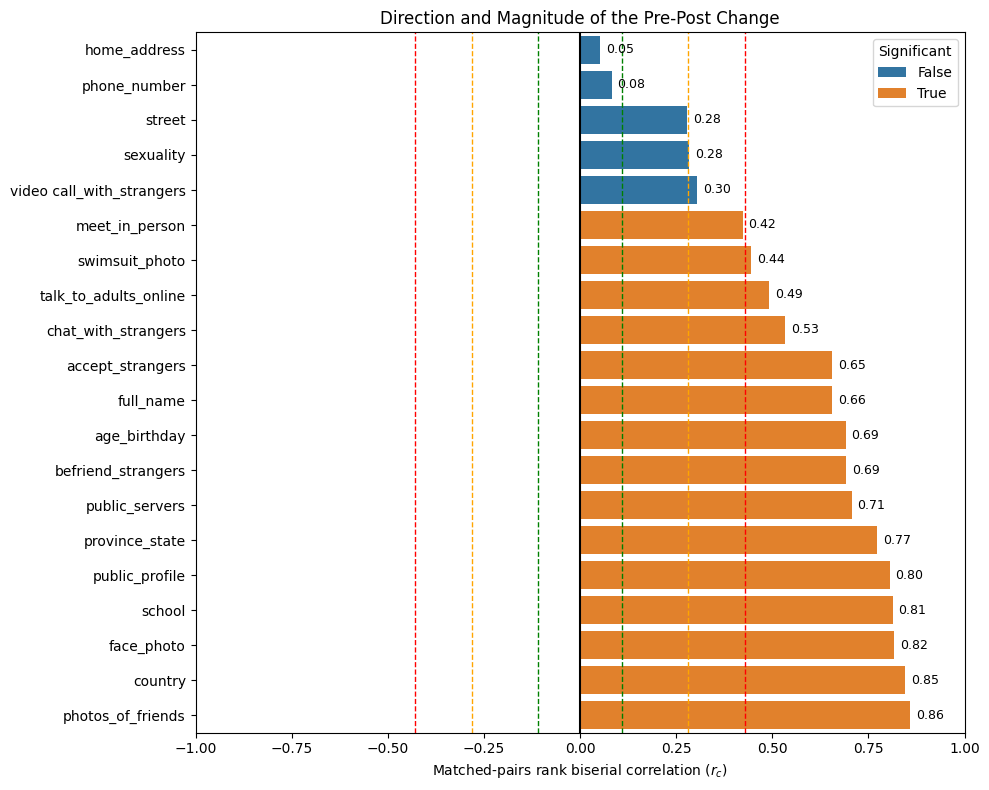

In [28]:
results_df["keyword"] = results_df["id"].map(id_to_keyword)

plot_df = (
	results_df
	.sort_values("rc_signed", ascending=True)
)

plt.figure(figsize=(10, 8))

ax = sns.barplot(
	data=plot_df,
	x="rc_signed",
	y="keyword",
	hue="significant",
	dodge=False
)

for i, (_, row) in enumerate(plot_df.iterrows()):
	x = row["rc_signed"]

	ax.text(
		x + (0.015 if x >= 0 else -0.015),
		i,
		f"{x:.2f}",
		va="center",
		ha="left" if x >= 0 else "right",
		fontsize=9
	)

# Sin cambio
plt.axvline(0, color="black", linewidth=1.5)

# Umbrales Vargha & Delaney para rank-biserial correlation
# Negativo: disminución pre-post
# Positivo: aumento pre-post
# Grande
plt.axvline(-0.43, color="red", linestyle="--", linewidth=1)
plt.axvline(0.43, color="red", linestyle="--", linewidth=1)

# Medio
plt.axvline(-0.28, color="orange", linestyle="--", linewidth=1)
plt.axvline(0.28, color="orange", linestyle="--", linewidth=1)

# Pequeño
plt.axvline(-0.11, color="green", linestyle="--", linewidth=1)
plt.axvline(0.11, color="green", linestyle="--", linewidth=1)

# Límites
plt.xlim(-1, 1)

plt.xlabel("Matched-pairs rank biserial correlation ($r_c$)")
plt.ylabel("")
plt.title("Direction and Magnitude of the Pre-Post Change")

plt.legend(title="Significant")

plt.tight_layout()
plt.show()


In [29]:
item_diff_df = (
	global_df
	.groupby("id")
	# Definir cómo se reduce cada columna por grupo
	.agg(
		# Tomar el primer item
		item=("item", "first"),
		pre=("pre", "mean"),
		post=("post", "mean"),
		diff=("diff", "mean"),
	)
	.reset_index()
)

display(item_diff_df)


,id,item,pre,post,diff
0,Q01,¿Cómo de peligrosas consideras las siguientes ...,3.913462,4.548077,0.634615
1,Q02,¿Cómo de peligrosas consideras las siguientes ...,4.375000,4.788462,0.413462
2,Q03,¿Cómo de peligrosas consideras las siguientes ...,3.759615,4.538462,0.778846
3,Q04,¿Cómo de peligrosas consideras las siguientes ...,4.500000,4.942308,0.442308
4,Q05,¿Cómo de peligrosas consideras las siguientes ...,4.923077,5.105769,0.182692
5,Q06,¿Cómo de peligrosas consideras las siguientes ...,4.346154,5.000000,0.653846
6,Q07,¿Cómo de peligrosas consideras las siguientes ...,5.019231,5.259615,0.240385
7,Q08,¿Cómo de peligrosas consideras las siguientes ...,4.932692,5.230769,0.298077
8,Q09,¿Cómo de peligrosas consideras las siguientes ...,4.086538,4.788462,0.701923
9,Q10,¿Cómo de peligrosas consideras las siguientes ...,4.067308,4.846154,0.778846


In [30]:
item_diff_df["keyword"] = item_diff_df["id"].map(id_to_keyword)

display(item_diff_df)


,id,item,pre,post,diff,keyword
0,Q01,¿Cómo de peligrosas consideras las siguientes ...,3.913462,4.548077,0.634615,public_profile
1,Q02,¿Cómo de peligrosas consideras las siguientes ...,4.375000,4.788462,0.413462,accept_strangers
2,Q03,¿Cómo de peligrosas consideras las siguientes ...,3.759615,4.538462,0.778846,public_servers
3,Q04,¿Cómo de peligrosas consideras las siguientes ...,4.500000,4.942308,0.442308,chat_with_strangers
4,Q05,¿Cómo de peligrosas consideras las siguientes ...,4.923077,5.105769,0.182692,video call_with_strangers
5,Q06,¿Cómo de peligrosas consideras las siguientes ...,4.346154,5.000000,0.653846,befriend_strangers
6,Q07,¿Cómo de peligrosas consideras las siguientes ...,5.019231,5.259615,0.240385,meet_in_person
7,Q08,¿Cómo de peligrosas consideras las siguientes ...,4.932692,5.230769,0.298077,talk_to_adults_online
8,Q09,¿Cómo de peligrosas consideras las siguientes ...,4.086538,4.788462,0.701923,face_photo
9,Q10,¿Cómo de peligrosas consideras las siguientes ...,4.067308,4.846154,0.778846,photos_of_friends


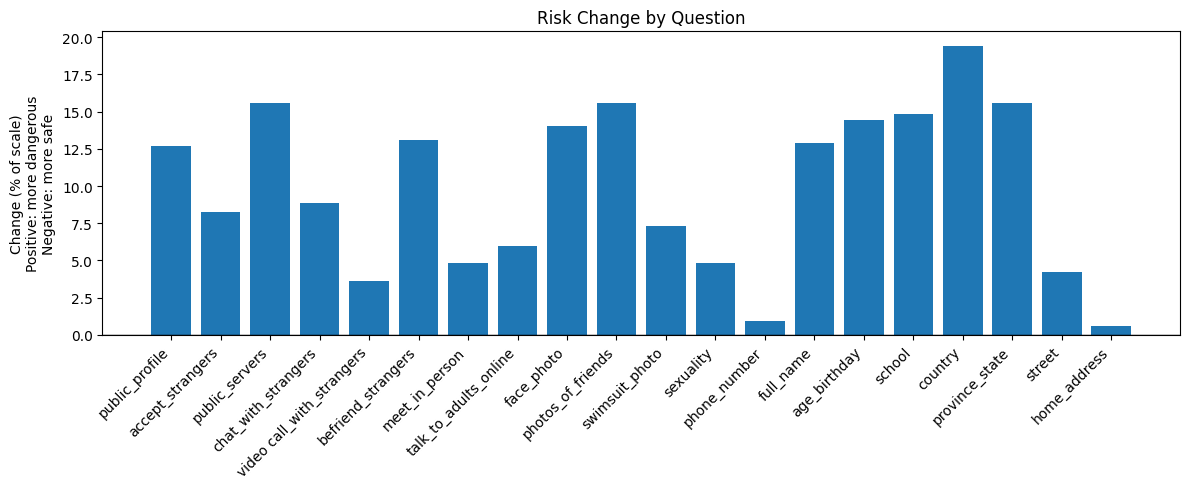

In [31]:
plt.figure(figsize=(12, 5))

normalized_diff = (item_diff_df["diff"] / 5) * 100

plt.bar(item_diff_df["keyword"], normalized_diff)

plt.axhline(0, color="black", linewidth=1)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Change (% of scale)\nPositive: more dangerous\nNegative: more safe")
plt.title("Risk Change by Question")

plt.tight_layout()
plt.show()


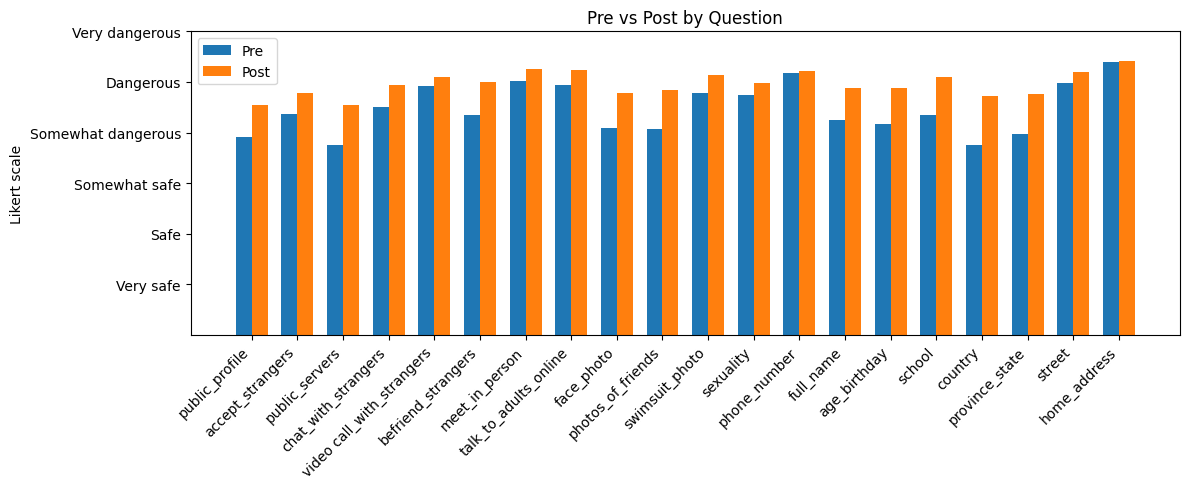

In [32]:
likert_labels = {
	1: "Very safe",
	2: "Safe",
	3: "Somewhat safe",
	4: "Somewhat dangerous",
	5: "Dangerous",
	6: "Very dangerous"
}

x = np.arange(len(item_diff_df))
width = 0.35

plt.figure(figsize=(12, 5))

plt.bar(x - width/2, item_diff_df["pre"], width, label="Pre")
plt.bar(x + width/2, item_diff_df["post"], width, label="Post")

plt.xticks(x, item_diff_df["keyword"], rotation=45, ha="right")
plt.yticks(list(likert_labels.keys()), list(likert_labels.values()))

plt.ylabel("Likert scale")
plt.title("Pre vs Post by Question")
plt.legend()

plt.tight_layout()
plt.show()
